In [43]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px
from matplotlib import colors
import math as math
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

Para entrenamiento mezclado

In [44]:
# data24_d = pd.read_pickle('data24_magdown_50_all.pkl')
# data24_u = pd.read_pickle('data24_magup_200_all.pkl')
# mc_data = pd.read_pickle('mc_data_all.pkl')

# data24 = pd.merge(data24_d,data24_u, how= 'outer')

Para entrenar solo MagDown

In [45]:
data24 = pd.read_pickle('data24_magdown_50_all.pkl')
mc_data = pd.read_pickle('mc_data_all.pkl')

Aqui hay que añadir las nuevas variables del DOCA y IP 

In [46]:
training_keys = ['Jpsi_PT','Jpsi_MAXDOCA', 'Jpsi_BPVDIRA', 'Jpsi_ETA', 
            'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2', 'L_PT','L_P', 'L_CHI2','L_END_VZ','L_END_VX', 'L_END_VY', 'L_MASS',
            'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT','Lb_CHI2','Lb_MINIPCHI2',  'Lb_ETA', 
            'p_PID_P', 'p_MINIP', 'p_P', 'p_PT', 'p_ETA','p_GHOSTPROB',
            'mup_PID_MU',
            'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB'] +['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP','DOCA','p_RK_IP','pim_RK_IP']

In [47]:
data24

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_ETA,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,...,pim_PZ_V,pim_X_V,pim_Y_V,p_TX,p_TY,pim_TX,pim_TY,DOCA,p_RK_IP,pim_RK_IP
0,1077.975830,5846.956055,2974.502686,54863.386719,1776.397949,4.123077,0.005935,0.002314,0.997817,1.207904,...,11680.919315,-10.835969,75.261326,-0.013627,0.018673,0.018514,0.019425,0.210603,49.721427,310.922226
1,1077.976562,5313.719238,3112.583496,58726.832031,1343.211792,4.470844,0.122067,0.009861,0.997888,1.222700,...,8786.270291,-147.728206,-50.450625,-0.016325,-0.013974,-0.058505,-0.013156,1.886890,77.313709,415.410681
2,1078.187256,6402.193359,3093.716309,18753.294922,2738.893555,2.611505,0.071255,0.009010,0.984698,1.317595,...,4819.569861,205.566897,-218.430465,-0.028050,-0.036172,0.252932,-0.036954,8.133840,30.332094,14.064989
3,1078.331421,5060.589355,3078.505615,36252.464844,492.338257,4.992107,1.107087,0.028151,0.996496,1.103896,...,7953.262103,-172.944417,-2.058991,-0.016683,0.003845,-0.030802,0.002457,0.484488,98.566212,649.269899
4,1078.344971,5300.834473,2953.872803,26179.085938,1636.410034,3.464616,1.147581,0.034740,0.992858,1.206773,...,16774.833827,-170.274727,-72.234454,-0.022561,-0.008554,-0.023594,-0.008810,0.028781,52.032315,348.617818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171843,1699.998535,5481.383789,3063.761230,65743.992188,1356.536865,4.573864,1.885007,0.041434,0.998666,1.301863,...,2459.657136,278.724574,375.612638,0.017463,0.046223,0.217304,0.065413,7.829135,88.920897,1093.558259
3171844,1699.998535,5328.483398,3022.227539,113000.929688,2035.559937,4.709600,0.013086,0.005731,0.999940,1.240183,...,29762.213420,-105.980358,-52.638200,-0.011106,-0.019972,-0.059777,-0.022595,28.573664,335.902751,364.482089
3171845,1699.998535,5363.164551,3069.586182,113130.843750,2043.669678,4.706774,0.005535,0.003733,0.999941,1.240008,...,29762.213420,-105.980358,-52.638200,-0.011106,-0.019972,-0.059777,-0.022595,28.573664,335.902751,364.482089
3171846,1699.999146,5104.324707,3084.939697,32234.619141,2095.427002,3.425304,1.892915,0.034274,0.999294,0.993032,...,5262.849624,31.525269,-186.931477,-0.035805,-0.037094,0.183826,-0.050636,18.277817,64.724714,147.996554


In [48]:
mc_data

,L_MASS,Lb_MASS,Jpsi_MASS,Jpsi_P,Jpsi_PT,Jpsi_CHI2,Jpsi_MAXDOCA,Jpsi_BPVDIRA,Jpsi_END_VRHO,Jpsi_END_VX,...,pim_PZ_V,pim_X_V,pim_Y_V,p_TX,p_TY,pim_TX,pim_TY,DOCA,p_RK_IP,pim_RK_IP
0,1078.216064,5238.732910,3095.558350,48452.062500,915.653381,0.299717,0.015202,0.999958,1.093754,0.9605,...,6347.434049,603.633899,-87.888160,0.028349,-0.024032,-0.178990,-0.023108,28.005986,20.274236,53.533973
1,1078.259033,5257.361816,3014.794678,145656.640625,6167.957520,0.607561,0.013176,0.999846,1.118636,1.0240,...,8304.830917,-799.335376,-75.248127,-0.061371,-0.024246,0.075773,-0.023438,0.688003,47.748954,17.751376
2,1078.478394,5378.423828,3104.240234,107524.718750,6373.708984,0.386113,0.031794,0.999907,1.743110,1.5966,...,15895.866282,-62.495240,-179.672997,0.007876,-0.042783,0.016770,-0.043573,0.342831,36.717005,317.756497
3,1078.545044,5452.856934,3114.653809,75249.507812,12491.000000,2.606676,0.030760,0.998852,1.256283,1.1800,...,4499.429765,460.188046,-250.966940,0.097050,-0.044477,0.066274,-0.039301,1.964708,142.260138,1106.174407
4,1078.846558,5150.160645,3109.953369,58382.671875,2565.219727,1.778421,0.030807,0.999737,1.657983,1.5057,...,5194.596327,551.206529,185.567668,0.084514,0.028904,0.097336,0.026315,1.887912,193.641135,1220.761827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60158,1699.889526,6187.048340,3113.975098,182840.265625,4920.676758,2.760785,0.033684,0.999967,1.260225,1.1663,...,10759.950513,-4.171114,-92.148110,0.052126,-0.023856,-0.094271,-0.046223,35.922793,11.415949,101.780203
60159,1699.902954,5329.004395,3107.208496,34801.566406,862.707825,2.338604,0.085805,0.999984,0.992543,0.9334,...,4704.339540,471.586803,114.132867,0.009876,0.030760,-0.133941,0.043626,25.148504,173.076008,438.230905
60160,1699.963257,5403.758301,3102.406738,30079.544922,1179.017822,0.439143,0.017408,0.999255,1.220537,1.1252,...,7392.959119,-514.084603,326.225829,0.000743,0.109228,0.056674,0.109514,1.631750,111.875900,423.918988
60161,1699.978271,6048.416992,3103.485107,179971.515625,9405.648438,1.092537,0.014153,0.999942,1.145118,1.0980,...,6395.929357,2.757377,-86.124568,0.061690,-0.018446,-0.152039,-0.002582,63.131394,7.296131,120.916184


In [49]:
to_drop1 = [x for x in mc_data.columns if x not in training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']+ ['L_MASS']+ ['MAGFIELD']]
to_drop2 = [x for x in data24.columns if x not in training_keys + ['Lb_MASS']+ ['L_MASS']]

In [50]:
print(to_drop1)
print(to_drop2)

['Jpsi_MASS', 'Jpsi_P', 'Jpsi_CHI2', 'Jpsi_END_VRHO', 'Jpsi_END_VX', 'Jpsi_END_VY', 'Jpsi_END_VZ', 'Jpsi_BPVIP', 'Jpsi_MINIPCHI2', 'L_PX', 'L_PY', 'L_PZ', 'L_BPVFDCHI2', 'L_MINIPCHI2', 'Lb_PX', 'Lb_PY', 'Lb_PZ', 'Lb_BPVIPCHI2', 'Lb_BPVFDCHI2', 'p_PX', 'p_PY', 'p_PZ', 'p_PID_K', 'pim_PX', 'pim_PY', 'pim_PZ', 'mum_P', 'mum_PT', 'mum_PX', 'mum_PY', 'mum_PZ', 'mum_CHI2', 'mum_GHOSTPROB', 'mum_PID_P', 'mum_PID_K', 'mum_PID_MU', 'mum_PID_E', 'mum_MINIP', 'mum_MINIPCHI2', 'mup_P', 'mup_PT', 'mup_PX', 'mup_PY', 'mup_PZ', 'mup_CHI2', 'mup_GHOSTPROB', 'mup_PID_P', 'mup_PID_K', 'mup_PID_E', 'mup_MINIP', 'mup_MINIPCHI2', 'totCandidates', 'p_QOVERP', 'pim_QOVERP', 'Lb_END_VX', 'Lb_END_VY', 'Lb_END_VZ', 'L_TRUEP', 'L_TRUEPX', 'L_TRUEPY', 'L_TRUEPZ', 'p_TRUEP', 'p_TRUEPX', 'p_TRUEPY', 'p_TRUEPZ', 'pim_TRUEP', 'pim_TRUEPX', 'pim_TRUEPY', 'pim_TRUEPZ', 'L_TRUEID', 'pim_TRUEID', 'p_TRUEID', 'p_TRUEENERGY', 'pim_TRUEENERGY', 'L_TRUEENERGY', 'p_MC_GD_MOTHER_ID', 'p_MC_MOTHER_ID', 'pim_MC_GD_MOTHER_ID', 'p

In [51]:
mc_data.drop(columns=to_drop1, inplace=True)
data24.drop(columns=to_drop2, inplace=True)

In [52]:
mc_data

,L_MASS,Lb_MASS,Jpsi_PT,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,L_END_VX,...,p_ETA,MAGFIELD,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2,DOCA,p_RK_IP,pim_RK_IP
0,1078.216064,5238.732910,915.653381,0.015202,0.999958,49633.324219,1198.487549,0.493996,3596.858398,33.169800,...,3.985816,True,0.999350,0.999636,0.026965,0.036062,1.753419,28.005986,20.274236,53.533973
1,1078.259033,5257.361816,6167.957520,0.013176,0.999846,62256.269531,3053.132568,0.011475,2773.745361,-158.011307,...,3.412443,True,0.999684,0.999827,0.018593,0.025122,4.277021,0.688003,47.748954,17.751376
2,1078.478394,5378.423828,6373.708984,0.031794,0.999907,131119.828125,5756.950195,0.187007,4225.615723,41.167599,...,3.828580,True,0.999912,0.999999,0.001145,0.013256,1.265592,0.342831,36.717005,317.756497
3,1078.545044,5452.856934,12491.000000,0.030760,0.998852,34788.062500,3542.150635,8.100865,5421.818848,510.521606,...,2.933115,False,0.999183,0.999990,0.004367,0.040418,22.678582,1.964708,142.260138,1106.174407
4,1078.846558,5150.160645,2565.219727,0.030807,0.999737,41821.460938,3772.997070,3.357353,6646.442383,581.727112,...,3.110670,False,0.999598,0.999997,0.002367,0.028365,5.225974,1.887912,193.641135,1220.761827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60158,1699.889526,6187.048340,4920.676758,0.033684,0.999967,42685.945312,1386.490356,13.284162,3964.677734,18.396299,...,3.552875,False,0.999413,0.999115,0.042082,0.034261,42.498470,35.922793,11.415949,101.780203
60159,1699.902954,5329.004395,862.707825,0.085805,0.999984,29330.285156,1015.178101,4.434874,4249.526367,-17.361300,...,4.125830,True,0.999426,0.999711,0.024026,0.033889,26.898869,25.148504,173.076008,438.230905
60160,1699.963257,5403.758301,1179.017822,0.017408,0.999255,27959.101562,3078.697998,0.042863,3206.360352,86.714798,...,2.910316,True,0.998213,0.999883,0.015286,0.059787,35.575795,1.631750,111.875900,423.918988
60161,1699.978271,6048.416992,9405.648438,0.014153,0.999942,37435.421875,1063.633667,9.623646,3555.705811,49.225800,...,3.436945,False,0.997711,0.999290,0.037690,0.067674,31.017563,63.131394,7.296131,120.916184


In [53]:
data24

,L_MASS,Lb_MASS,Jpsi_PT,Jpsi_ETA,Jpsi_MAXDOCA,Jpsi_BPVDIRA,L_P,L_PT,L_CHI2,L_END_VZ,...,pim_GHOSTPROB,mup_PID_MU,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2,DOCA,p_RK_IP,pim_RK_IP
0,1077.975830,5846.956055,1776.397949,4.123077,0.002314,0.997817,88352.117188,1860.207520,0.103174,4249.742188,...,0.162915,7.493675,0.999991,0.999902,0.004257,0.014029,1.332619,0.210603,49.721427,310.922226
1,1077.976562,5313.719238,1343.211792,4.470844,0.009861,0.997888,68503.218750,1763.939941,0.112574,3882.144775,...,0.113319,0.347026,0.999985,0.999979,0.005426,0.006496,1.834390,1.886890,77.313709,415.410681
2,1078.187256,6402.193359,2738.893555,2.611505,0.009010,0.984698,36373.828125,1361.485962,0.012034,5504.375977,...,0.020753,12.058558,0.999327,0.999409,0.036701,0.034373,8.643069,8.133840,30.332094,14.064989
3,1078.331421,5060.589355,492.338257,4.992107,0.028151,0.996496,56604.093750,1075.201782,0.629229,4587.109863,...,0.277531,6.811736,0.999998,0.999966,0.002072,0.008250,24.885163,0.484488,98.566212,649.269899
4,1078.344971,5300.834473,1636.410034,3.464616,0.034740,0.992858,127491.195312,3093.562744,0.001181,7442.494141,...,0.675442,8.349495,1.000000,0.999871,0.000000,0.016058,5.839044,0.028781,52.032315,348.617818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3171843,1699.998535,5481.383789,1356.536865,4.573864,0.041434,0.998666,36091.449219,1945.027832,23.219116,7282.461914,...,0.632257,3.353277,0.999908,0.999131,0.013567,0.041682,56.004918,7.829135,88.920897,1093.558259
3171844,1699.998535,5328.483398,2035.559937,4.709600,0.005731,0.999940,49281.320312,2024.946411,56.315197,4906.027344,...,0.346232,1.909957,0.999682,0.999649,0.025236,0.026490,90.689325,28.573664,335.902751,364.482089
3171845,1699.998535,5363.164551,2043.669678,4.706774,0.003733,0.999941,49281.320312,2024.946411,56.315197,4906.027344,...,0.346232,1.909957,0.999682,0.999649,0.025236,0.026488,90.677596,28.573664,335.902751,364.482089
3171846,1699.999146,5104.324707,2095.427002,3.425304,0.034274,0.999294,25580.609375,1106.434814,5.147719,4923.417969,...,0.372198,2.916568,0.998954,0.999546,0.045752,0.030123,17.154321,18.277817,64.724714,147.996554


In [54]:
training_data = mc_data[mc_data['MAGFIELD'] == False].copy() # True for MagUP and False for MagDown
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['L_MASS'] < 1400) 
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True

In [55]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

13366


In [56]:
new_training = pd.DataFrame(columns=training_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
# new_training = new_training.merge(data24_selected,how='outer')
new_training = new_training.merge(data24.query('(L_MASS > 1400) & (L_MASS < 1700) '),how='outer')

# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_29993/1454980834.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [57]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

13366
1436257


In [58]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [59]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP', 'L_MASS', 'MAGFIELD'] #, ,'xi_L', 'xi_Lb'
# to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','xi_LbP', 'xi_LP'] #, 'Cos_xi_LbP','Cos_xi_LP'

In [60]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [61]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [62]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [63]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.203911
0:	learn: 0.3902482	total: 114ms	remaining: 1m 53s
1:	learn: 0.2540804	total: 223ms	remaining: 1m 51s
2:	learn: 0.1801291	total: 341ms	remaining: 1m 53s
3:	learn: 0.1478206	total: 457ms	remaining: 1m 53s
4:	learn: 0.1214571	total: 558ms	remaining: 1m 51s
5:	learn: 0.1075880	total: 664ms	remaining: 1m 50s
6:	learn: 0.0994801	total: 772ms	remaining: 1m 49s
7:	learn: 0.0913687	total: 877ms	remaining: 1m 48s
8:	learn: 0.0866324	total: 979ms	remaining: 1m 47s
9:	learn: 0.0821879	total: 1.08s	remaining: 1m 46s
10:	learn: 0.0781942	total: 1.19s	remaining: 1m 46s
11:	learn: 0.0746557	total: 1.29s	remaining: 1m 46s
12:	learn: 0.0718091	total: 1.4s	remaining: 1m 46s
13:	learn: 0.0694902	total: 1.5s	remaining: 1m 45s
14:	learn: 0.0669767	total: 1.61s	remaining: 1m 45s
15:	learn: 0.0650636	total: 1.71s	remaining: 1m 45s
16:	learn: 0.0635092	total: 1.81s	remaining: 1m 44s
17:	learn: 0.0618635	total: 1.92s	remaining: 1m 44s
18:	learn: 0.0603541	total: 2.04s	remaining: 1

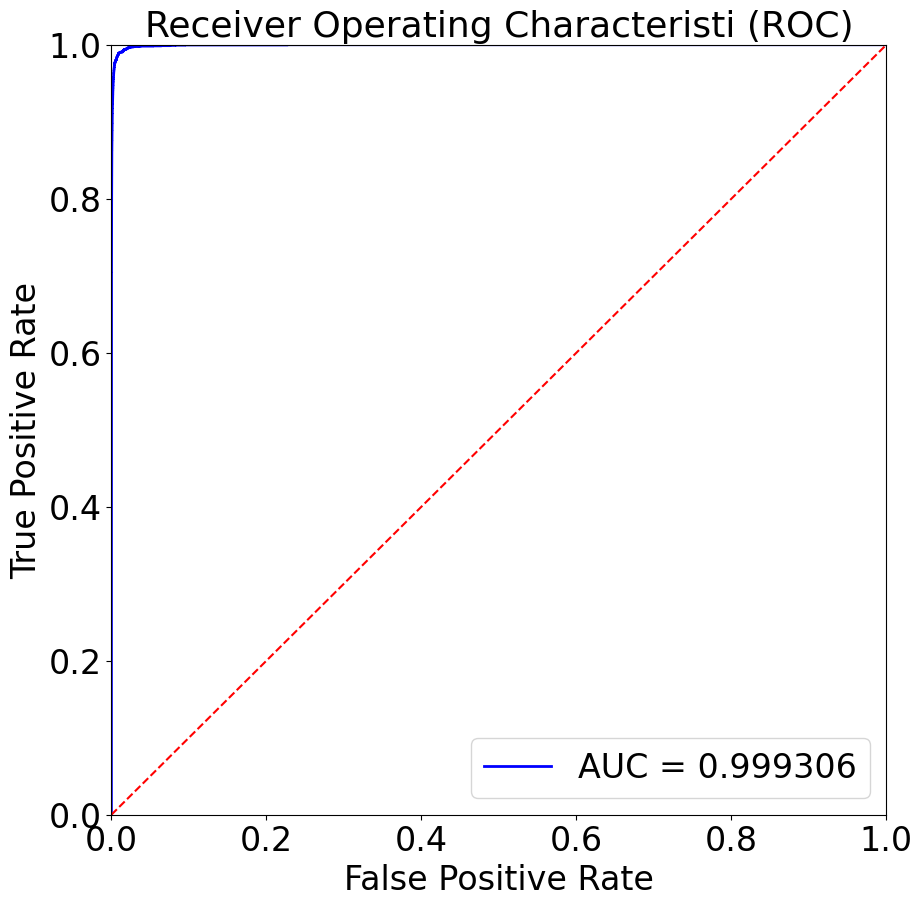

In [64]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)
plt.title('Receiver Operating Characteristi (ROC)', fontsize=26)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=24)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=24)
plt.xlabel('False Positive Rate', fontsize=24)
plt.xticks(fontsize=24) 
plt.yticks(fontsize=24) 
plt.show()

In [65]:
print(model.get_best_score())
print(model.get_all_params())

{'learn': {'Accuracy:use_weights=true': 0.9984524420494266, 'Logloss:use_weights=false': 0.008593368414806138, 'Logloss:use_weights=true': 0.006593254018516558, 'Logloss': 0.006593254018516558, 'Accuracy:use_weights=false': 0.9969334548668757, 'AUC': 0.9999229732961561}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39],
 [Text(0, 0, 'L_END_VY'),
  Text(0, 1, 'Lb_MAXDOCA'),
  Text(0, 2, 'L_END_VX'),
  Text(0, 3, 'L_BPVDIRA'),
  Text(0, 4, 'Jpsi_ETA'),
  Text(0, 5, 'Jpsi_PT'),
  Text(0, 6, 'p_ETA'),
  Text(0, 7, 'Lb_CHI2'),
  Text(0, 8, 'L_BPVIPCHI2'),
  Text(0, 9, 'xi_LbP'),
  Text(0, 10, 'pim_ETA'),
  Text(0, 11, 'Lb_P'),
  Text(0, 12, 'Lb_PT'),
  Text(0, 13, 'p_PID_P'),
  Text(0, 14, 'Lb_ETA'),
  Text(0, 15, 'L_CHI2'),
  Text(0, 16, 'L_BPVIP'),
  Text(0, 17, 'p_P'),
  Text(0, 18, 'p_RK_IP'),
  Text(0, 19, 'mup_PID_MU'),
  Text(0, 20, 'pim_PT'),
  Text(0, 21, 'Jpsi_MAXDOCA'),
  Text(0, 22, 'p_PT'),
  Text(0, 23, 'pim_RK_IP'),
  Text(0, 24, 'Lb_MINIPCHI2'),
  Text(0, 25, 'L_PT'),
  Text(0, 26, 'DOCA'),
  Text(0, 27, 'Jpsi_BPVDIRA'),
  Text(0, 28, 'Lb_BPVVDRHO'),
  Text(0, 29,

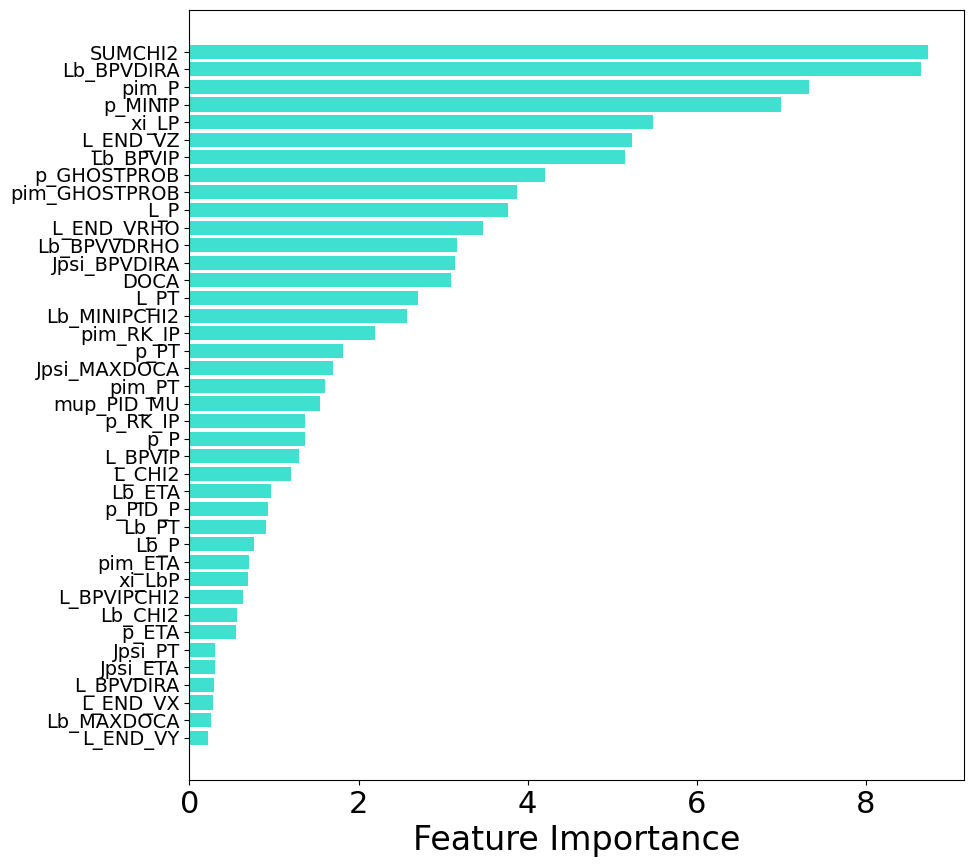

In [66]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (10,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=22)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=14)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [67]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

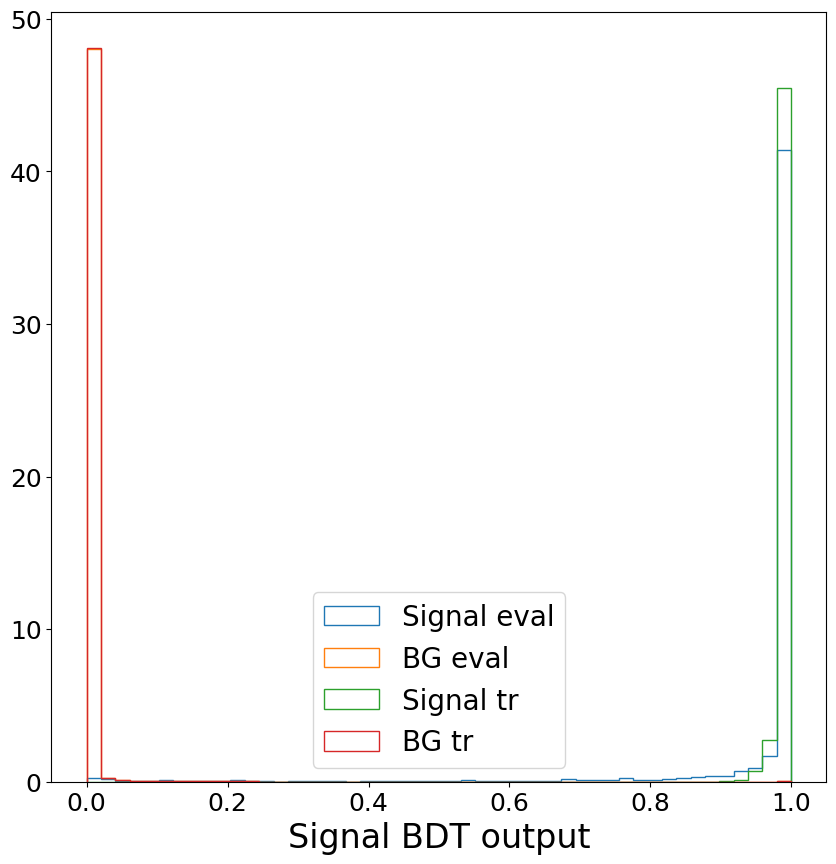

In [68]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

Guarda el modelo para ser utilizado posteriormente

In [69]:
model.save_model('BDT_MagDown_all',
           format="cbm",
           export_parameters=None,
           pool=None)

In [70]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 13366
SIGNAL == False 1436257


: 